In [16]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from glob import glob
import os
from utils import *
from sklearn.decomposition import PCA
from skimage.morphology import remove_small_holes, remove_small_holes



## Manual Extraction of Reference Cards

In the next cells, we manually crop the reference images into individual UNO card symbols such as numbers, skip, reverse, plus, wild, etc. For each symbol, we also separate the different card colors. These cropped examples form the base dataset used later for classification.

In [17]:
reference_folder = folder_test = r"C:\Users\USER\Desktop\Uno project\reference_images"

references = []
for path in glob(os.path.join(reference_folder, "*")):
    img = cv2.imread(path, cv2.IMREAD_COLOR_RGB)

    if img is not None:
        references.append(img)

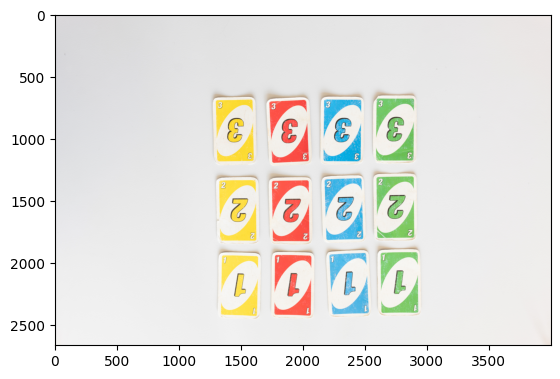

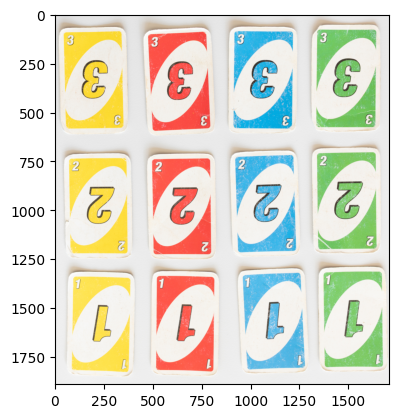

In [18]:
plt.imshow(references[0])
plt.show()
one_two_three = references[0][600:2490,1250:2960]
plt.imshow(one_two_three)

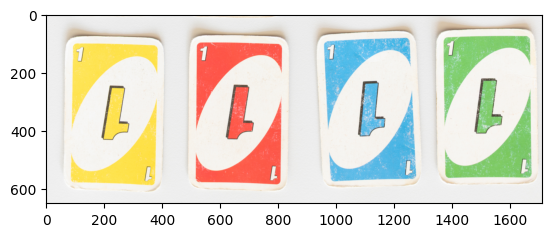

In [19]:
one = one_two_three[1240:]
plt.imshow(one)

In [20]:
one_yellow = one[20:,60:400]
one_red = one[40:,490:840]
one_blue = one[20:-20,940:1290]
one_green = one[20:-20,1350:-10]

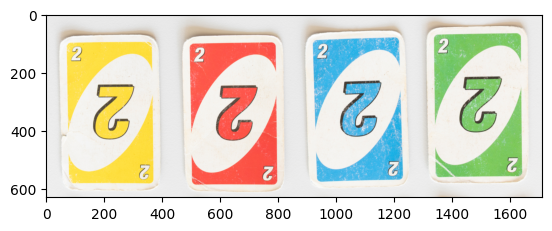

In [21]:
two = one_two_three[640:1270]
plt.imshow(two)

In [22]:
two_yellow = two[10:,50:390]
two_red = two[10:,470:820]
two_blue = two[:-20,900:1250]
two_green = two[:-20,1290:-10]

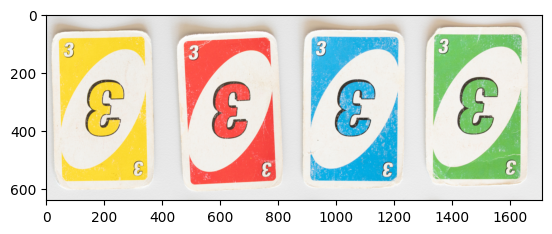

In [23]:
three = one_two_three[10:650]
plt.imshow(three)

In [24]:
three_yellow = three[20:,20:380]
three_red = three[20:,430:850]
three_blue = three[20:-10,890:1240]
three_green = three[:-20,1310:-30]

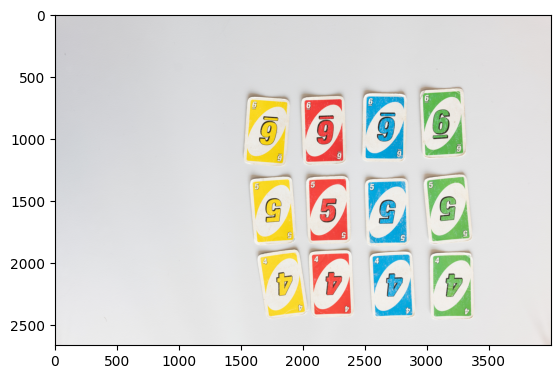

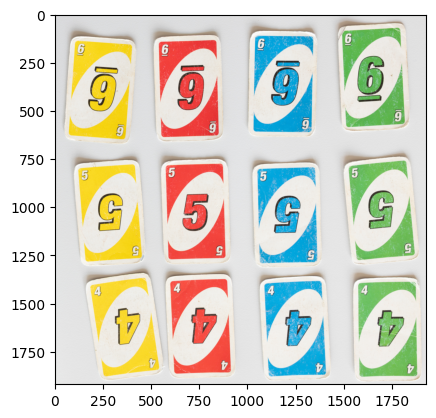

In [25]:
plt.imshow(references[1])
plt.show()
four_five_six = references[1][550:2470,1470:3400]
plt.imshow(four_five_six)

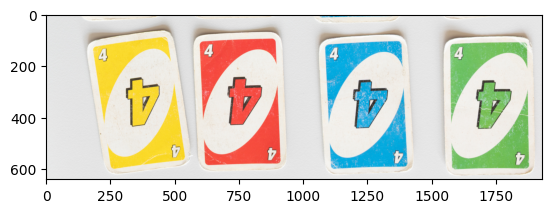

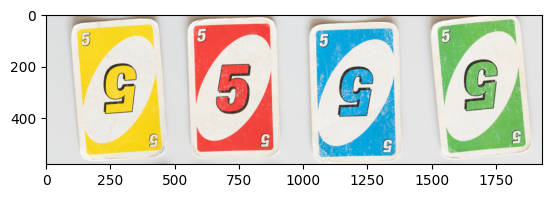

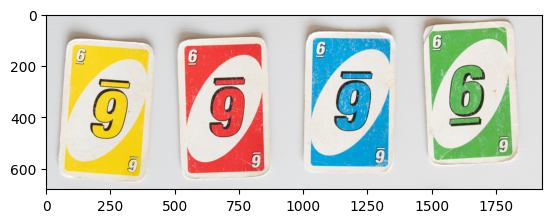

In [26]:
four = four_five_six[1280:]
five = four_five_six[740:1320]
six = four_five_six[20:700]
plt.imshow(four)
plt.show()
plt.imshow(five)
plt.show()
plt.imshow(six)
plt.show()

In [27]:
four_yellow = four[40:-20,160:560]
four_red = four[30:-10,560:950]
four_blue = four[30:-10,1050:1450]
four_green = four[60:-10,1530:-10]

In [28]:
five_yellow = five[20:-20,100:460]
five_red = five[10:-20,550:910]
five_blue = five[10:,1010:1400]
five_green = five[10:-20,1500:-40]

In [29]:
six_yellow = six[90:-20,50:420]
six_red = six[70:-20,490:890]
six_blue = six[60:-60,1000:1360]
six_green = six[:-70,1450:-70]

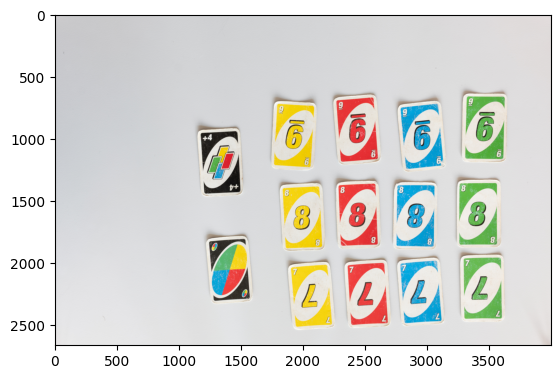

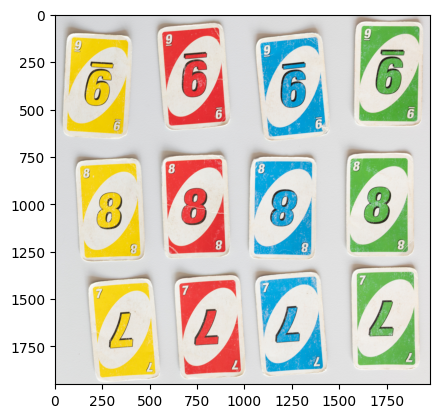

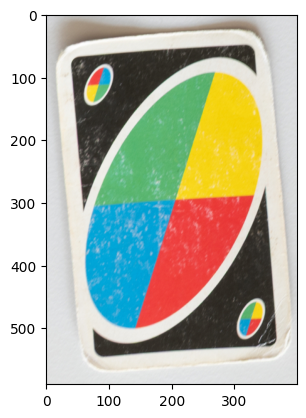

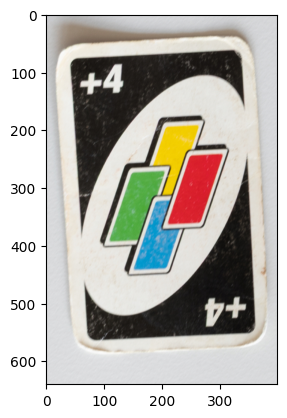

In [30]:
plt.imshow(references[2])
plt.show()
seven_eight_nine = references[2][600:2550,1700:3680]
plt.imshow(seven_eight_nine)
plt.show()
wild = references[2][1760:2350,1200:1600]
plt.imshow(wild)
plt.show()
plus4 = references[2][880:1520,1130:1530]
plt.imshow(plus4)
plt.show()

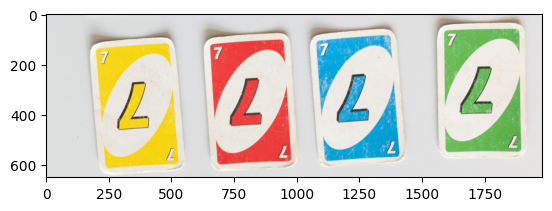

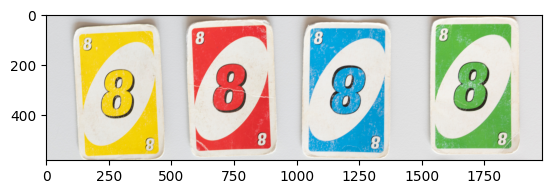

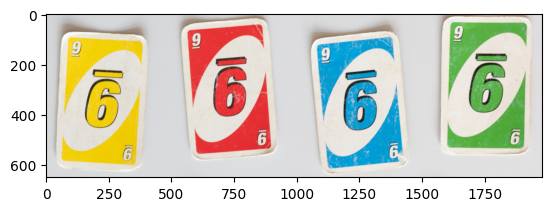

In [31]:
seven = seven_eight_nine[1300:]
eight = seven_eight_nine[720:1300]
nine = seven_eight_nine[30:680]
plt.imshow(seven)
plt.show()
plt.imshow(eight)
plt.show()
plt.imshow(nine)
plt.show()

In [32]:
seven_yellow = seven[90:-20,170:550]
seven_red = seven[70:-30,630:1000]
seven_blue = seven[30:-20,1040:1450]
seven_green = seven[30:-70,1550:-60]

In [33]:
eight_yellow = eight[40:,110:470]
eight_red = eight[20:-20,560:920]
eight_blue = eight[30:-10,1020:1380]
eight_green = eight[10:-20,1530:-90]

In [34]:
nine_yellow = nine[60:-30,40:400]
nine_red = nine[:-50,520:950]
nine_blue = nine[40:,1040:1470]
nine_green = nine[:-60,1550:-10]

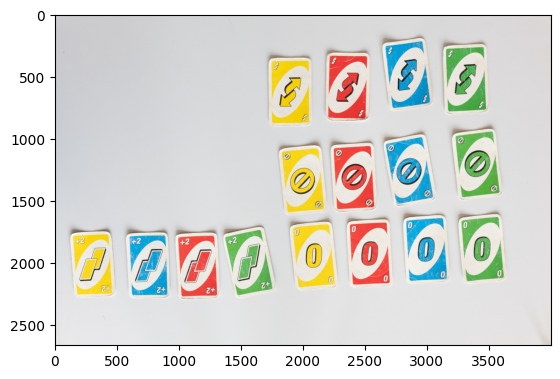

In [35]:
plt.imshow(references[3])

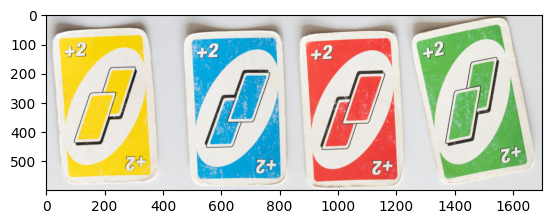

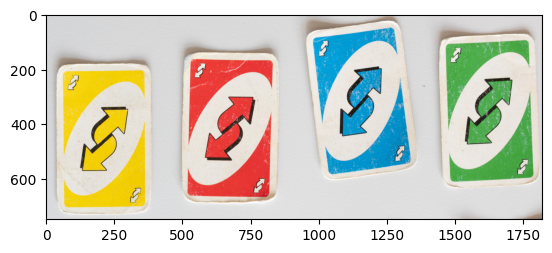

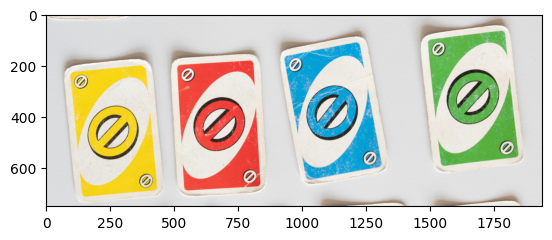

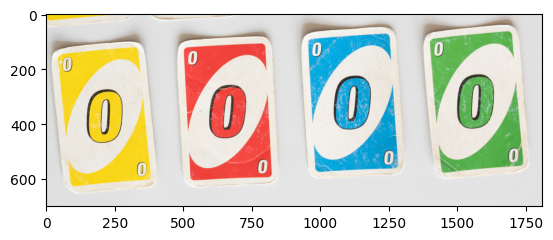

In [36]:
plus2s = references[3][1700:2300, 100:1800]
reverses = references[3][170:920, 1680:3500]
skips = references[3][880:1630, 1730:3670]
zeros = references[3][1570:2270, 1870:3680]
plt.imshow(plus2s)
plt.show()
plt.imshow(reverses)
plt.show()
plt.imshow(skips)
plt.show()
plt.imshow(zeros)
plt.show()

In [37]:
plus2_yellow = plus2s[:,:400]
plus2_blue = plus2s[:,450:850]
plus2_red = plus2s[:,850:1250]
plus2_green = plus2s[:, 1250:]

In [38]:
reverse_yellow = reverses[150:,:400]
reverse_red = reverses[100:-30,470:870]
reverse_blue = reverses[:650,930:1400]
reverse_green = reverses[40:650, 1420:]

In [39]:
skip_yellow = skips[140:,50:480]
skip_red = skips[120:-30,470:880]
skip_blue = skips[50:700,890:1350]
skip_green = skips[:650, 1430:1890]

In [40]:
zero_yellow = zeros[50:-10,:430]
zero_red = zeros[40:-50,450:870]
zero_blue = zeros[10:630,910:1330]
zero_green = zeros[:620, 1350:1790]

## Special Case: 6 / 9 Discrimination

The digits 6 and 9 produce very similar contours, especially when the card is rotated. Therefore, instead of relying only on Fourier descriptors only, we introduced an additional geometric disambiguation step. Our method detects the small underline used on UNO cards and determines its position relative to the main digit body. After normalizing the symbol orientation, this information helps decide whether the detected shape corresponds to a 6 or a 9. To handle cases where the underline is not initially horizontal, our method also tests several rotated versions of the crop. However, this remains a potential limitation, as very noisy, partial, or poorly oriented detections may still make the underline difficult to identify reliably.


In [66]:
def to_gray(img):
    """
    Convert RGB/BGR/gray image to grayscale.
    For 6/9 geometry, exact RGB/BGR order does not matter much.
    """
    if img.ndim == 2:
        return img.copy()
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


def crop_content(mask, pad=8):
    """
    Crop binary mask to its non-zero content.
    """
    ys, xs = np.where(mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return mask

    x0 = max(0, xs.min() - pad)
    x1 = min(mask.shape[1], xs.max() + pad + 1)
    y0 = max(0, ys.min() - pad)
    y1 = min(mask.shape[0], ys.max() + pad + 1)

    return mask[y0:y1, x0:x1]


def dark_mask_for_six_nine(img, out_size=(140, 200)):
    """
    Extract dark strokes of the 6/9 symbol, including underline.
    """
    gray = to_gray(img)
    gray = cv2.resize(gray, out_size, interpolation=cv2.INTER_AREA)

    # Dark digit outline + underline.
    mask = (gray < 130).astype(np.uint8) * 255

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
        iterations=1,
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2)),
        iterations=1,
    )

    return mask


def find_underline(mask, debug=False):
    """
    Find the underline as the strongest long horizontal component.

    Returns:
        underline dict or None
        horizontal underline mask
    """
    H, W = mask.shape[:2]

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (int(0.20 * W), 3),
    )

    horiz = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        horizontal_kernel,
        iterations=1,
    )

    num, labels, stats, centroids = cv2.connectedComponentsWithStats(
        horiz,
        connectivity=8,
    )

    candidates = []

    for i in range(1, num):
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]

        aspect = w / max(h, 1)

        if w >= 0.15 * W and aspect >= 3.0 and area >= 15:
            score = float(w * area)

            candidates.append(
                {
                    "score": score,
                    "x": x,
                    "y": y,
                    "w": w,
                    "h": h,
                    "cx": float(cx),
                    "cy": float(cy),
                    "area": float(area),
                    "aspect": float(aspect),
                }
            )

    if len(candidates) == 0:
        return None, horiz

    best = max(candidates, key=lambda c: c["score"])

    return best, horiz

def rotate_by_90(img, angle):
    """
    Rotate image by 0, 90, 180, or 270 degrees.
    """
    angle = angle % 360

    if angle == 0:
        return img.copy()
    elif angle == 90:
        return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    elif angle == 180:
        return cv2.rotate(img, cv2.ROTATE_180)
    elif angle == 270:
        return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    else:
        raise ValueError("angle must be one of 0, 90, 180, 270")


def normalize_underline_below(img, debug=False):
    """
    Normalize a 6/9 crop orientation, In order to make underline consistently below the digit body.

    """
    candidates = []

    for angle in [0, 90, 180, 270]:
        img_rot = rotate_by_90(img, angle)

        mask = dark_mask_for_six_nine(img_rot)
        underline, horiz = find_underline(mask)

        if underline is None:
            continue

        # Remove underline to estimate digit body center.
        body = mask.copy()
        body[horiz > 0] = 0

        ys, xs = np.where(body > 0)

        if len(ys) == 0:
            continue

        body_center_y = float(0.5 * (ys.min() + ys.max()))
        line_y = float(underline["cy"])

        candidates.append(
            {
                "angle": angle,
                "img_rot": img_rot,
                "mask": mask,
                "horiz": horiz,
                "underline": underline,
                "line_y": line_y,
                "body_center_y": body_center_y,
                "score": underline["score"],
            }
        )

    if len(candidates) == 0:
        mask = dark_mask_for_six_nine(img)

        if debug:
            print("No underline found in any rotation.")

        return img.copy(), {
            "rotated": False,
            "base_rotation": 0,
            "flipped_180": False,
            "reason": "underline_not_found",
            "mask": mask,
            "horiz": np.zeros_like(mask),
        }

    # Best rotation = strongest horizontal underline.
    best = max(candidates, key=lambda c: c["score"])

    img_norm = best["img_rot"]
    line_y = best["line_y"]
    body_center_y = best["body_center_y"]

    # If underline is above body, digit is upside down after base rotation.
    flipped_180 = line_y < body_center_y

    if flipped_180:
        img_norm = cv2.rotate(img_norm, cv2.ROTATE_180)

    if debug:
        print(
            f"base_rotation={best['angle']}°, "
            f"line_y={line_y:.1f}, "
            f"body_center_y={body_center_y:.1f}, "
            f"flipped_180={flipped_180}"
        )

        debug_vis = cv2.cvtColor(best["mask"], cv2.COLOR_GRAY2RGB)

        cv2.line(
            debug_vis,
            (0, int(line_y)),
            (best["mask"].shape[1], int(line_y)),
            (255, 0, 0),
            2,
        )

        cv2.line(
            debug_vis,
            (0, int(body_center_y)),
            (best["mask"].shape[1], int(body_center_y)),
            (0, 255, 0),
            2,
        )

        fig, axes = plt.subplots(1, 5, figsize=(16, 4))
        axes[0].imshow(img)
        axes[0].set_title("input")
        axes[1].imshow(best["img_rot"])
        axes[1].set_title(f"base rot {best['angle']}°")
        axes[2].imshow(best["mask"], cmap="gray")
        axes[2].set_title("dark mask")
        axes[3].imshow(best["horiz"], cmap="gray")
        axes[3].set_title("underline")
        axes[4].imshow(debug_vis)
        axes[4].set_title("red=line, green=body")

        for ax in axes:
            ax.axis("off")

        plt.show()

    return img_norm, {
        "rotated": best["angle"] != 0 or flipped_180,
        "base_rotation": best["angle"],
        "flipped_180": flipped_180,
        "reason": "ok",
        "mask": best["mask"],
        "horiz": best["horiz"],
        "line_y": line_y,
        "body_center_y": body_center_y,
        "underline_score": best["score"],
    }


def six_nine_geometry_feature(img, debug=False):
    """
    Return a geometric feature for upright 6/9.

    After underline normalization:
    - six should have more digit mass lower
    - nine should have more digit mass upper

    Feature = lower_mass - upper_mass.
    Higher usually means six.
    Lower usually means nine.
    """
    img_norm, info = normalize_underline_below(img, debug=debug)

    mask = dark_mask_for_six_nine(img_norm)

    underline, horiz = find_underline(mask)

    # Remove underline before measuring digit shape.
    if horiz is not None:
        mask[horiz > 0] = 0

    mask = crop_content(mask, pad=4)
    mask = cv2.resize(mask, (80, 120), interpolation=cv2.INTER_NEAREST)

    H, W = mask.shape[:2]

    # Use thirds to avoid the middle noisy region.
    upper = mask[: H // 3, :]
    lower = mask[2 * H // 3 :, :]

    upper_mass = np.sum(upper > 0)
    lower_mass = np.sum(lower > 0)

    feature = (lower_mass - upper_mass) / max(lower_mass + upper_mass, 1)

    if debug:
        print(
            f"upper_mass={upper_mass}, lower_mass={lower_mass}, "
            f"feature={feature:.3f}"
        )

        fig, axes = plt.subplots(1, 3, figsize=(9, 3))
        axes[0].imshow(img_norm)
        axes[0].set_title("upright crop")
        axes[1].imshow(mask, cmap="gray")
        axes[1].set_title("body mask")
        axes[2].bar(["upper", "lower"], [upper_mass, lower_mass])
        axes[2].set_title(f"feature={feature:.3f}")
        plt.show()

    return feature, info


def build_six_nine_geometry_threshold(debug=False):
    """
    Calibrate 6/9 threshold from reference crops.

    Assumption:
        six_yellow, six_red, ..., nine_green are already crops of the 6/9 symbol,
        not full card images. So we do NOT use center_symbol_roi().
    """
    six_refs = [
        six_yellow,
        six_red,
        six_blue,
        six_green,
    ]

    nine_refs = [
        nine_yellow,
        nine_red,
        nine_green,
    ]

    if "nine_blue" in globals():
        nine_refs.append(nine_blue)

    six_features = []
    nine_features = []

    for img in six_refs:
        feat, _ = six_nine_geometry_feature(img)
        six_features.append(feat)

    for img in nine_refs:
        feat, _ = six_nine_geometry_feature(img)
        nine_features.append(feat)

    six_mean = float(np.mean(six_features))
    nine_mean = float(np.mean(nine_features))

    threshold = 0.5 * (six_mean + nine_mean)

    # Decide direction automatically:
    # if six has larger feature, feature > threshold means six.
    six_is_greater = six_mean > nine_mean

    if debug:
        print("six_features :", six_features)
        print("nine_features:", nine_features)
        print("six_mean:", six_mean)
        print("nine_mean:", nine_mean)
        print("threshold:", threshold)
        print("six_is_greater:", six_is_greater)

    return {
        "threshold": threshold,
        "six_mean": six_mean,
        "nine_mean": nine_mean,
        "six_is_greater": six_is_greater,
    }


six_nine_geometry_model = build_six_nine_geometry_threshold(debug=True)


def discriminate_six_nine(normalized_card, debug=False):
    """
    Final 6/9 discriminator.

    Uses:
    1. underline to normalize orientation
    2. geometric mass feature to decide six vs nine
    """
    feature, info = six_nine_geometry_feature(normalized_card, debug=debug)

    threshold = six_nine_geometry_model["threshold"]
    six_is_greater = six_nine_geometry_model["six_is_greater"]

    if six_is_greater:
        pred = "six" if feature > threshold else "nine"
    else:
        pred = "six" if feature < threshold else "nine"

    if debug:
        print(
            f"feature={feature:.3f}, threshold={threshold:.3f}, "
            f"prediction={pred}, rotated={info.get('rotated')}"
        )

    return pred

six_features : [np.float64(0.32919254658385094), np.float64(-0.03557312252964427), np.float64(-0.2903225806451613), np.float64(0.5104895104895105)]
nine_features: [np.float64(0.36551724137931035), np.float64(0.03522205206738132), np.float64(-0.7304347826086957), np.float64(0.6206896551724138)]
six_mean: 0.12844658847463897
nine_mean: 0.07274854150260246
threshold: 0.10059756498862071
six_is_greater: True


## Contour Detection

Now we want to detect candidate symbols by filtering the image, removing small objects, and extracting contours. The goal here is to isolate meaningful UNO symbols while rejecting noise or irrelevant image regions.

In [67]:
def detect_number_contours(img, dilation_kernel = 2, min_area=300, max_area=2200, thr_solidity=0.8, corners=8):
    """
    Args:
        img: Input RGB image
        dilation_kernel: Kernel size for dilation
        min_area: Minimum contour area (filter out noise)
        max_area: Maximum contour area (filter out large regions)
        
    Returns:
        List of valid card contours, edges, dilated image
    """
    # Convert to grayscale for edge detection
    #gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = card_only_filter_blank(img)
    gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
    gray = ~remove_small_objects(~gray.astype(np.uint8), min_size=min_area).astype(np.uint8)
    # Canny edge detection
    
    # Apply dilation to connect nearby edges
    
    # Find contours
    contours, _ = cv2.findContours(gray, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter contours based on area and shape
    valid_contours = []
    for contour in contours:
        area = cv2.contourArea(contour)
        # Filter by area
        if area < min_area or area > max_area:
            continue
        # # Get the convex hull
        # hull = cv2.convexHull(contour)
        # hull_area = cv2.contourArea(hull)
        
        # # Calculate solidity
        # if hull_area > 0:
        #     solidity = float(area) / hull_area
        #     if solidity < thr_solidity: 
        #         continue
        
        # Approximate contour to polygon
        '''
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        
        if len(approx) >= corners:'''
        valid_contours.append(contour)
    
    return valid_contours

In [68]:
def plot_contours(image, contours, color=(0, 255, 0), thickness=2):
    """
    Draw contours returned by cv2.findContours.

    Parameters
    ----------
    image : np.ndarray
        Input image (grayscale or BGR).
    contours : list
        Contours returned by cv2.findContours.
    color : tuple
        Contour color in BGR.
    thickness : int
        Line thickness.
    """

    # Convert grayscale to BGR for colored drawing
    if len(image.shape) == 2:
        output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        output = image.copy()

    # Draw all contours
    cv2.drawContours(output, contours, -1, color, thickness)

    # Display with matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

## Classification

We decided to use Fourier descriptors in order to convert each detected contour into a compact numerical representation of its shape. We found that this was more suitable than direct template matching, which is what we originally tried, because the detected card symbols are not always perfectly aligned, centered, or scaled in the same way. Template matching is sensitive to these variations: even small changes in rotation, contour thickness, perspective, or crop size can significantly reduce the matching score. Since our card detection step is based on contours extracted from real images, the resulting symbol crops can vary depending on lighting, card orientation, and segmentation quality.

For this reason, we switched to Fourier descriptors, which provide a more robust shape-based representation. By describing the contour in the frequency domain, our method captures the global structure of the symbol rather than comparing pixels directly. The descriptors are known for the fact that when normalized, they can be mostly invariant to translation, scale, and rotation, which is important because UNO cards can appear at different positions and angles in the image. This makes the classifier better at generalizing to new test images, especially when the extracted contours are not identical to the reference examples. In practice, this allowed us to classify digits and action symbols more reliably from segmented contours.

In [86]:
def fourier_descriptors(contours, n_samples=100, interpolation=True):
    """
    Compute translation and rotation invariant Fourier descriptors.

    Also returns:
    - contour center
    - dominant contour rotation

    Parameters
    ----------
    contours : list of (K,2) arrays
    n_samples : int
    interpolation : bool

    Returns
    -------
    descriptors : (N, n_samples-1)
        Translation + rotation invariant descriptors.

    centers : (N, 2)
        Contour centroids.

    rotations : (N,)
        Dominant contour orientation in radians.
    """

    descriptors = []
    centers = []
    rotations = []

    for contour in contours:

        contour = np.asarray(contour.squeeze(), dtype=np.float64)
        d = np.sqrt(np.sum(np.diff(contour, axis=0)**2, axis=1))
        t = np.concatenate([[0], np.cumsum(d)])

        t_new = np.linspace(0, t[-1], n_samples)
        x = np.interp(t_new, t, contour[:, 0])
        y = np.interp(t_new, t, contour[:, 1])

        contour = np.stack([x, y], axis=1)

        center = contour.mean(axis=0)
        centers.append(center)

        z = contour[:, 0] + 1j * contour[:, 1]
        fd = np.fft.fft(z)
        fd[0] = 0

        rotation = np.angle(fd[1])
        rotations.append(rotation)
        fd *= np.exp(-1j * rotation)
        descriptors.append(np.abs(fd[1:]))

    return (
        np.array(descriptors),
        np.array(centers),
        np.array(rotations)
    )

In [70]:
def rotate_image(image, angle):
    """
    Rotate image without cropping.

    Parameters
    ----------
    image : np.ndarray
    angle : float
        Rotation angle in degrees.
        Positive = counter-clockwise

    Returns
    -------
    rotated : np.ndarray
    """

    h, w = image.shape[:2]
    center = (w / 2, h / 2)

    # Rotation matrix
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Compute new bounding dimensions
    cos = abs(M[0, 0])
    sin = abs(M[0, 1])

    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))

    # Adjust translation
    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]

    # Rotate
    rotated = cv2.warpAffine(image, M, (new_w, new_h))

    return rotated

In [71]:
def manual_filter(descriptors, contours, card_type):
    descriptors_out, contours_out = [], []
    if card_type == 'one':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[0] < 1700 and descriptor[0] > 1200:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
                
    if card_type == 'zero':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[0] < 2300 and descriptor[0] > 2000:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
    
    if card_type == 'two':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[0] > 1300 and descriptor[3]<200:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
                
    if card_type == 'three':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[0] > 1350 and descriptor[0] < 1550:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
                
    if card_type == 'four':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[0] > 1600 and descriptor[0] < 1900:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
                
    if card_type == 'five':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[0] > 1300 and descriptor[0] < 1550:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
                
    if card_type == 'six-nine':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[1] > 750 and descriptor[1] < 1050:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
    
    if card_type == 'seven':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[0] > 1400 and descriptor[0] < 1750 and descriptor[1]>200 and descriptor[1]<600:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
    
    if card_type == 'eight':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[0] > 1900 and descriptor[1] < 2200 and descriptor[0] < 2500:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
                
    if card_type == 'nine':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[1] > 750 and descriptor[1] < 1050:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
                
    if card_type == 'reverse':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[0] > 1050 and descriptor[0] < 1300:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
                
    if card_type == 'skip':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[0] > 2400 and descriptor[0] < 2600:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
                
    if card_type == 'plus':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[2] < 150 and descriptor[0] > 1000 and descriptor[0] < 1500 and descriptor[1] < 200:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
                
    if card_type == 'wild':
        for idx, descriptor in enumerate(descriptors):
            if descriptor[0] > 400 and descriptor[0] < 650:
                descriptors_out.append(descriptor)
                contours_out.append(contours[idx])
    
    
    return descriptors_out, contours_out

In [72]:
def build_rotated_descriptor_dataset(images, label, n_rotations=11, angle_step=18):

    rotated_images = [[] for _ in images]
    contours_all = [[] for _ in images]
    descriptors_all = [[] for _ in images]

    if label == 'plus4' or label == 'plus2':
        label = 'plus'
    for img_idx, img in enumerate(images):

        for rot_idx in range(n_rotations):

            angle = rot_idx * angle_step
            rotated = rotate_image(img, angle=angle)
            valid_contours = detect_number_contours(rotated)
            descriptors, _, _ = fourier_descriptors(valid_contours)
            rotated_images[img_idx].append(rotated)
            segmented_descriptors, segmented_contours = manual_filter(descriptors, valid_contours, label)
            contours_all[img_idx].append(segmented_contours)
            descriptors_all[img_idx].extend(segmented_descriptors[:2])

    return (
        rotated_images,
        contours_all,
        np.array(descriptors_all)
    )

In [73]:
image_groups = {
    "zero": [zero_blue, zero_green, zero_red, zero_yellow],
    "one": [one_blue, one_green, one_red, one_yellow],
    "two": [two_blue, two_green, two_red, two_yellow],
    "three": [three_blue, three_green, three_red, three_yellow],
    "four": [four_blue, four_green, four_red, four_yellow],
    "five": [five_blue, five_green, five_red, five_yellow],
    "six-nine": [six_blue, six_green, six_red, six_yellow, nine_green, nine_red, nine_yellow],
    "seven": [seven_blue, seven_green, seven_red, seven_yellow],
    "eight": [eight_blue, eight_green, eight_red, eight_yellow],
    "reverse": [reverse_blue, reverse_green, reverse_red, reverse_yellow],
    "skip": [skip_blue, skip_green, skip_red, skip_yellow],
    "plus": [plus2_blue, plus2_green, plus2_red, plus2_yellow, plus4],
    "wild": [wild],
}

datasets = {}
all_images = {}
all_contours = {}

for label, imgs in image_groups.items():

    rotated_imgs, contours, descriptors = build_rotated_descriptor_dataset(imgs, label, n_rotations=21, angle_step=9)

    all_images[label] = rotated_imgs
    all_contours[label] = contours

    datasets[label] = np.concatenate(descriptors, axis=0)

C:\Users\USER\AppData\Local\Temp\ipykernel_20668\895638765.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
c:\Users\USER\Documents\GitHub\group14_iapr454\iapr\Lib\site-packages\skimage\_shared\utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
C:\Users\USER\AppData\Local\Temp\ipykernel_20668\895638765.py:16: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` in

[[1638.01092212  908.68741804  246.12804725 ...  182.42146694
   146.40389114  516.5920722 ]
 [1677.91995496  885.07428494  277.28721772 ...  164.58356873
   119.56776632  524.41996421]
 [1635.5887301   911.03617214  243.86893929 ...  188.76567587
   142.99519676  507.14954265]
 ...
 [1577.55818028  816.60925583  256.48800865 ...  179.38196623
   145.48603204  525.01900401]
 [1628.28220768  869.38669867  263.53908752 ...  165.29387129
   128.8263782   529.36787557]
 [1557.97199607  850.34765733  239.64772662 ...  183.63009233
   154.09124669  528.32434641]]


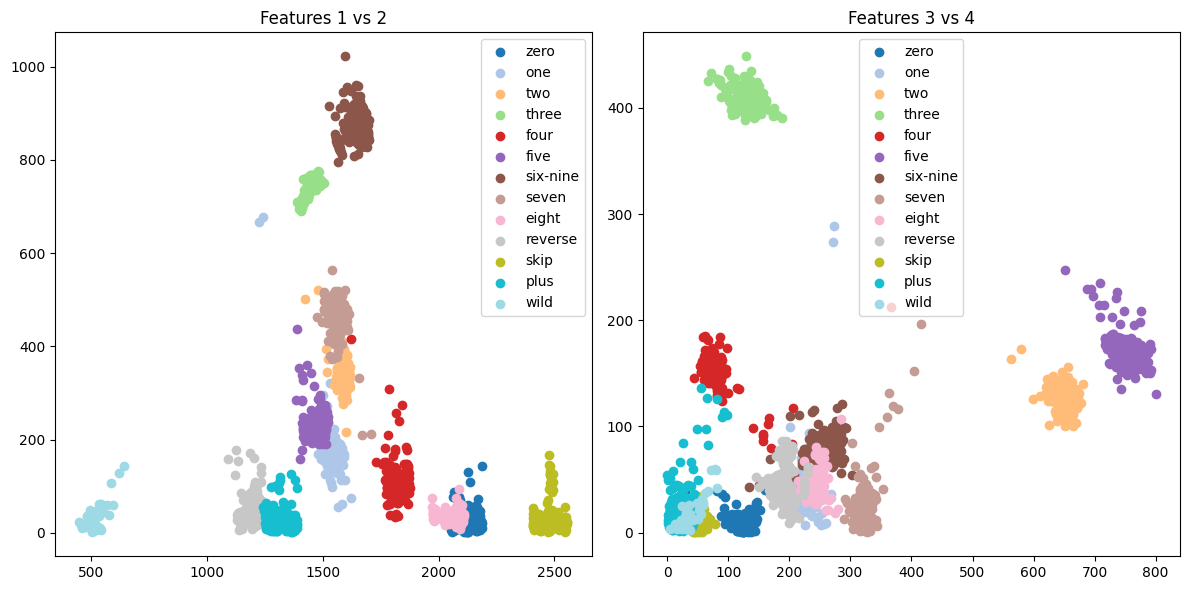

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

colors = plt.cm.tab20(np.linspace(0, 1, len(datasets)))

for (label, data), color in zip(datasets.items(), colors):
    if label == 'six-nine':
        print(data)
    axes[0].scatter(
        data[:, 0],
        data[:, 1],
        label=label,
        color=color
    )

    axes[1].scatter(
        data[:, 2],
        data[:, 3],
        label=label,
        color=color
    )

axes[0].set_title("Features 1 vs 2")
axes[1].set_title("Features 3 vs 4")

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_20668\895638765.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
C:\Users\USER\AppData\Local\Temp\ipykernel_20668\895638765.py:16: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = ~remove_small

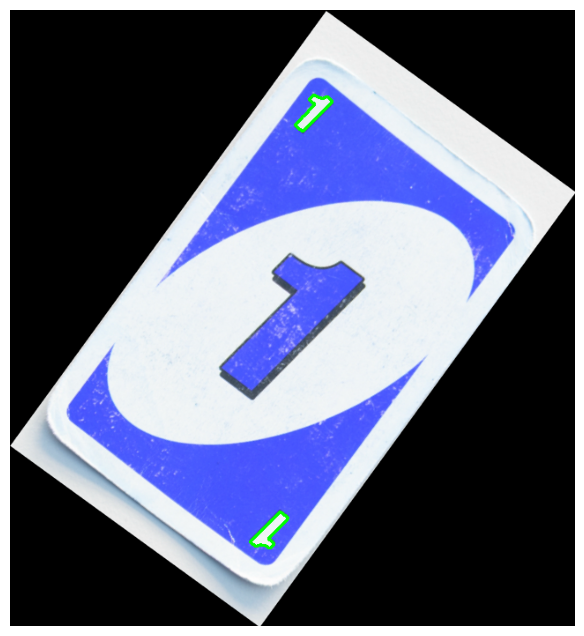

[667.58187449 128.59491026]
481.48523491534354


In [75]:
test_img = one_red
i = 16
angle = 9*i
rotated = rotate_image(test_img, angle=angle)
valid_contours_test = detect_number_contours(rotated)
descriptors_test, centers, _ = fourier_descriptors(valid_contours_test)
#descriptors_test, valid_contours_test = manual_filter(descriptors_test, valid_contours_test, 'one')
_ = plot_contours(rotated, valid_contours_test)
print(np.array(descriptors_test)[:,1])
print(np.sqrt(np.sum((centers[0]-centers[1])**2)))

r


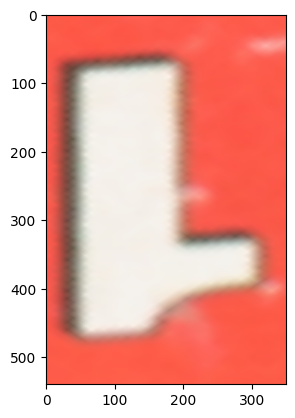

In [76]:
normalized_card = extract_and_normalize_card(rotated, valid_contours_test[1], extension=10)
plt.imshow(normalized_card)
print(classify_card_color(normalized_card))

C:\Users\USER\AppData\Local\Temp\ipykernel_20668\895638765.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
C:\Users\USER\AppData\Local\Temp\ipykernel_20668\895638765.py:16: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = ~remove_small

yellow:
angle (0) i=0, lenght=2,descriptor1: [1529 1525],descriptor2: [158 168],descriptor3: [224 234],descriptor4: [40 21]
angle (9) i=1, lenght=2,descriptor1: [1514 1541],descriptor2: [163 186],descriptor3: [216 218],descriptor4: [56 39]
angle (18) i=2, lenght=2,descriptor1: [1519 1539],descriptor2: [144 177],descriptor3: [228 223],descriptor4: [40 28]
angle (27) i=3, lenght=2,descriptor1: [1533 1540],descriptor2: [164 164],descriptor3: [223 224],descriptor4: [19 32]
angle (36) i=4, lenght=2,descriptor1: [1523 1538],descriptor2: [165 156],descriptor3: [223 221],descriptor4: [27 44]
angle (45) i=5, lenght=2,descriptor1: [1493 1498],descriptor2: [158 174],descriptor3: [229 236],descriptor4: [53 22]
angle (54) i=6, lenght=2,descriptor1: [1511 1522],descriptor2: [126 191],descriptor3: [229 224],descriptor4: [49 26]
angle (63) i=7, lenght=2,descriptor1: [1505 1540],descriptor2: [154 158],descriptor3: [223 217],descriptor4: [48 32]
angle (72) i=8, lenght=2,descriptor1: [1531 1537],descript

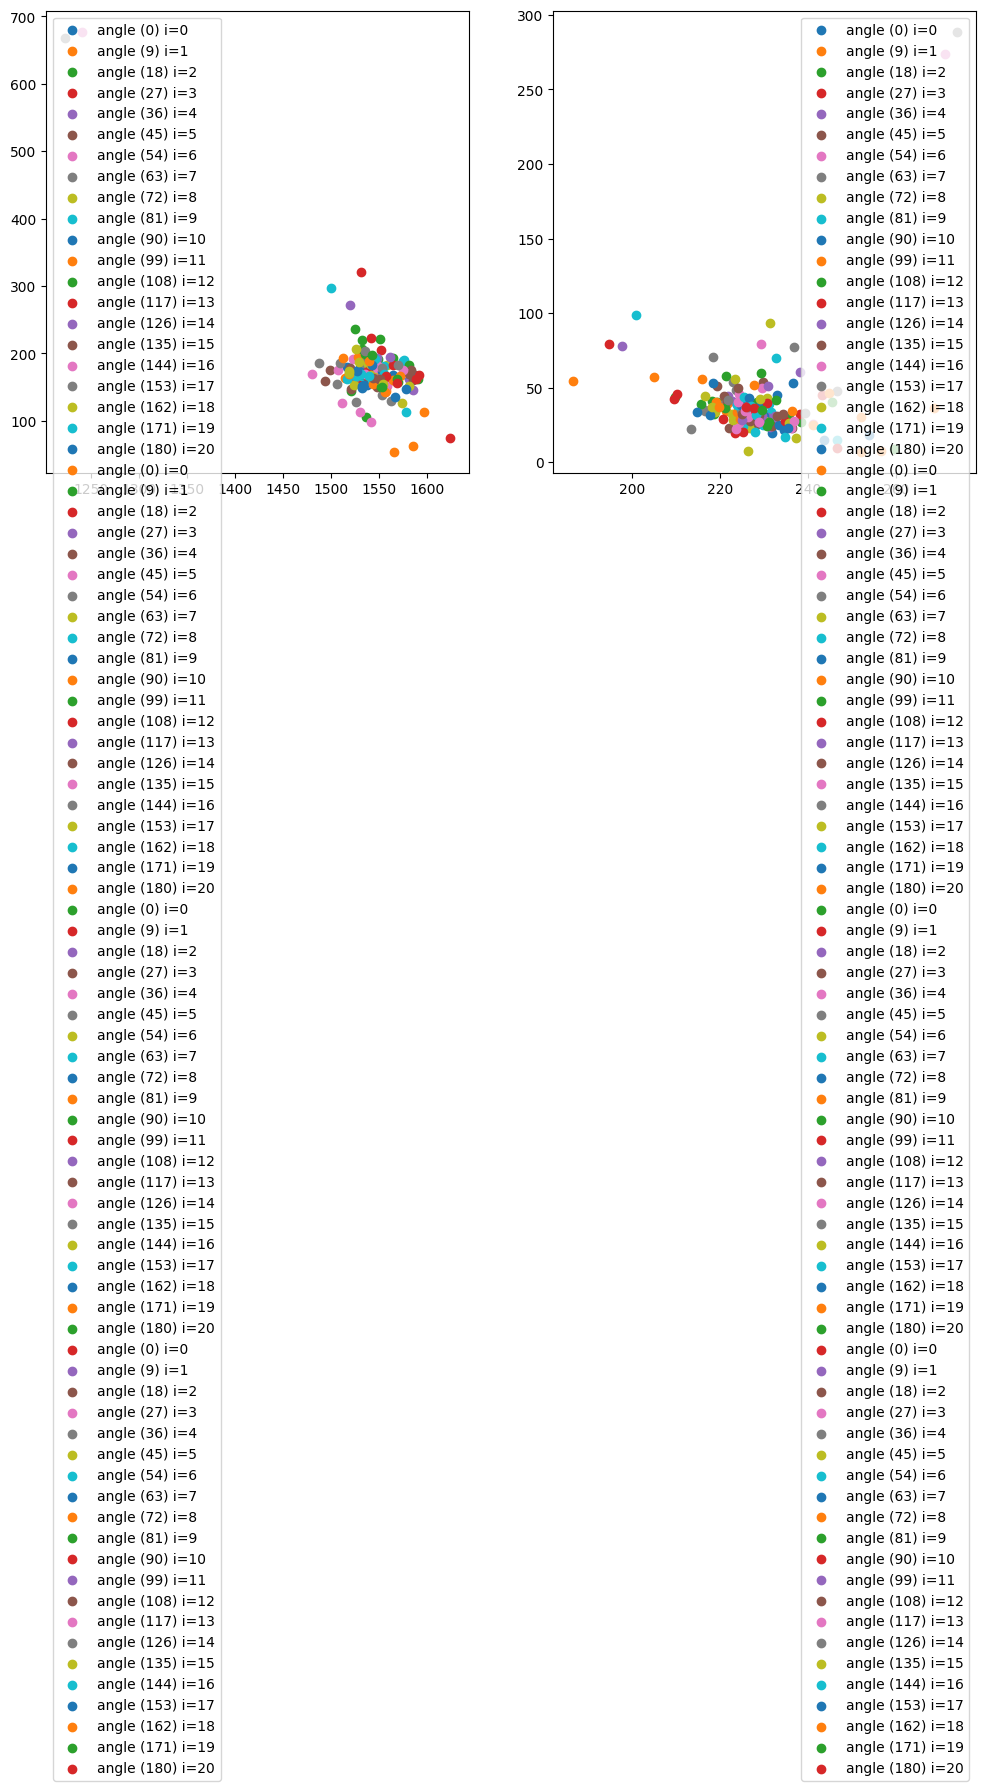

In [77]:
test_imgs = [one_yellow, one_red, one_blue, one_green]
names = ['yellow', 'red', 'blue', 'green']
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for idx, test_img in enumerate(test_imgs):
    print(f'{names[idx]}:')
    for i in range(21):
        angle = 9*i
        rotated = rotate_image(test_img, angle=angle)
        valid_contours_test = detect_number_contours(rotated)
        descriptors_test, _, _ = fourier_descriptors(valid_contours_test)
        #descriptors_test, _ = manual_filter(descriptors_test, valid_contours_test, 'seven')
        descriptors_test = np.array(descriptors_test)
        print(f'angle ({angle}) i={i}, lenght={len(descriptors_test)},'\
            f'descriptor1: {np.array(descriptors_test[:,0],dtype=np.uint(16))},'\
            f'descriptor2: {np.array(descriptors_test[:,1],dtype=np.uint(16))},'\
            f'descriptor3: {np.array(descriptors_test[:,2],dtype=np.uint(16))},'\
                f'descriptor4: {np.array(descriptors_test[:,3],dtype=np.uint(16))}')
        axes[0].scatter(descriptors_test[:,0],descriptors_test[:,1], label=f'angle ({angle}) i={i}')
        axes[1].scatter(descriptors_test[:,2],descriptors_test[:,3], label=f'angle ({angle}) i={i}')
        #segmented_contours = []
        '''for idx, descriptor in enumerate(descriptors_test):
            if descriptor[1]<1000:
                segmented_contours.append(valid_contours_test[idx])'''
        #_ = plot_contours(rotated, segmented_contours)
    axes[0].legend()
    axes[1].legend()


In [78]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score


def build_classifier_dataset(datasets):
    """
    Convert dictionary of descriptor datasets into X / y arrays.
    """

    X = []
    y = []

    for label, data in datasets.items():

        data = np.asarray(data)

        # flatten descriptors if needed
        data = data.reshape(data.shape[0], -1)

        X.append(data)
        y.extend([label] * len(data))

    X = np.vstack(X)
    y = np.array(y)

    return X, y


def train_simple_discriminator(
    datasets,
    test_size=0.2,
    n_neighbors=3,
    random_state=42
):
    """
    Train a simple KNN discriminator on Fourier descriptors.
    """

    # build full dataset
    X, y = build_classifier_dataset(datasets)

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    # classifier
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)

    # train
    clf.fit(X_train, y_train)

    # predict
    y_pred = clf.predict(X_test)

    # metrics
    acc = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred))

    return clf

In [79]:
from sklearn.preprocessing import StandardScaler

class FourierDiscriminator:

    def __init__(
        self,
        n_neighbors=3,
        rejection_threshold=2.0
    ):

        self.scaler = StandardScaler()

        self.knn = KNeighborsClassifier(
            n_neighbors=n_neighbors
        )

        self.rejection_threshold = rejection_threshold

    def fit(
        self,
        datasets,
        test_size=0.2,
        random_state=42
    ):

        X, y = build_classifier_dataset(datasets)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            stratify=y,
            random_state=random_state
        )

        # normalize descriptors
        X_train = self.scaler.fit_transform(X_train)
        X_test = self.scaler.transform(X_test)

        self.knn.fit(X_train, y_train)

        y_pred = self.knn.predict(X_test)

        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(f"Macro F1 : {f1_score(y_test, y_pred, average='macro'):.4f}\n")

        print(classification_report(y_test, y_pred))

    def predict(self, descriptor):

        descriptor = np.asarray(descriptor).reshape(1, -1)

        # normalize
        descriptor = self.scaler.transform(descriptor)

        distances, _ = self.knn.kneighbors(descriptor)

        # normalized mean neighbor distance
        mean_distance = distances.mean()

        if mean_distance > self.rejection_threshold:
            return "None", mean_distance

        prediction = self.knn.predict(descriptor)[0]

        if prediction == "six-nine":
            prediction = discriminate_six_nine(
                normalized_card,
                debug=False,
            )

        return prediction, mean_distance


def evaluate_image(
    image,
    truth_label,
    classifier
):
    """
    Evaluate all contours of one image against truth label.
    """

    contours = detect_number_contours(image)
    descriptors_list, _, _ = fourier_descriptors(contours)

    predictions = []

    print(f"\nGround truth: {truth_label}\n")

    for i, descriptor in enumerate(descriptors_list):

        descriptor = np.asarray(descriptor).flatten()

        pred, dist = classifier.predict(descriptor)

        # force scalar string
        pred = str(pred)


        predictions.append(pred)

        print(
            f"Contour {i:02d} | "
            f"Prediction: {pred:<10} | "
            f"Distance: {dist:.3f}"
        )

    # remove unknown predictions
    predictions = [p for p in predictions if p != "None"]

    predicted_set = set(predictions)
    truth_set = set(truth_label)

    print("\nDetected labels :", predicted_set)
    print("Expected labels :", truth_set)

    # ===== SET-BASED METRICS =====

    true_positive = len(predicted_set & truth_set)

    precision = (
        true_positive / len(predicted_set)
        if len(predicted_set) > 0 else 0
    )

    recall = (
        true_positive / len(truth_set)
        if len(truth_set) > 0 else 0
    )

    if precision + recall == 0:
        f1 = 0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    print(f"\nPrecision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 score  : {f1:.4f}")

    return f1

In [80]:
#img_test_classifier = cv2.imread("D:/pattern_analysis/group14_iapr454/project/test_images/L1000796.jpg");
img_test_classifier = cv2.imread(r"C:\Users\USER\Desktop\Uno project\test_images\L1000796.jpg");
true_value = ['seven', 'seven', 'six-nine', 'six-nine', 'five', 'five', 'six-nine', 'six-nine', 'two', 'two', 'six-nine', 'six-nine', 'skip', 'skip', 'plus', 'plus', 'one', 'one', 'wild', 'wild']
rejection_thresholds = [9.58]
n_neighbors = [1]
best_f1 = 0
best_n = None
best_rj = None
for rejection_threshold in rejection_thresholds:
    for n in n_neighbors:
        classifier = FourierDiscriminator(n_neighbors=n, rejection_threshold=rejection_threshold)
        classifier.fit(datasets)
        print(f'n: {n} | rt: {rejection_threshold}')
        f1 = evaluate_image(img_test_classifier,truth_label=true_value,classifier=classifier)
        if f1 > best_f1:
            best_f1 = f1
            best_n = n
            best_rj = rejection_threshold

Accuracy: 0.9350
Macro F1 : 0.9367

              precision    recall  f1-score   support

       eight       0.94      1.00      0.97        34
        five       1.00      0.91      0.95        33
        four       1.00      0.88      0.94        34
         one       0.93      0.76      0.84        34
        plus       0.95      1.00      0.98        42
     reverse       0.69      0.97      0.80        34
       seven       1.00      0.97      0.98        33
    six-nine       1.00      0.97      0.98        59
        skip       0.86      0.94      0.90        34
       three       1.00      1.00      1.00        34
         two       0.97      0.97      0.97        33
        wild       1.00      1.00      1.00         8
        zero       0.93      0.79      0.86        34

    accuracy                           0.93       446
   macro avg       0.94      0.94      0.94       446
weighted avg       0.94      0.93      0.94       446

n: 1 | rt: 9.58


C:\Users\USER\AppData\Local\Temp\ipykernel_20668\895638765.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
c:\Users\USER\Documents\GitHub\group14_iapr454\iapr\Lib\site-packages\skimage\_shared\utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
C:\Users\USER\AppData\Local\Temp\ipykernel_20668\895638765.py:16: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` in


Ground truth: ['seven', 'seven', 'six-nine', 'six-nine', 'five', 'five', 'six-nine', 'six-nine', 'two', 'two', 'six-nine', 'six-nine', 'skip', 'skip', 'plus', 'plus', 'one', 'one', 'wild', 'wild']

Contour 00 | Prediction: six        | Distance: 6.643
Contour 01 | Prediction: skip       | Distance: 4.885
Contour 02 | Prediction: zero       | Distance: 5.045
Contour 03 | Prediction: six        | Distance: 7.117
Contour 04 | Prediction: skip       | Distance: 6.107
Contour 05 | Prediction: plus       | Distance: 6.375
Contour 06 | Prediction: two        | Distance: 5.896
Contour 07 | Prediction: None       | Distance: 10.255
Contour 08 | Prediction: plus       | Distance: 6.652
Contour 09 | Prediction: one        | Distance: 6.741
Contour 10 | Prediction: six        | Distance: 6.017
Contour 11 | Prediction: six        | Distance: 5.765
Contour 12 | Prediction: None       | Distance: 22.763
Contour 13 | Prediction: None       | Distance: 11.843
Contour 14 | Prediction: reverse    | Dist

In [81]:
best_rj

9.58

In [82]:
def deduplicate_predictions(
    predictions,
    duplicate_distance_thresh=10,
    pair_distance_target=480,
    pair_distance_margin=50,
    angle_thresh=15
):
    """
    Keep only one prediction when:
    - same class
    - same color
    - same angle
    - AND centers are either:
        * extremely close (duplicate)
        * OR separated by ~480 +/- margin
    """

    kept = []

    for pred in predictions:

        keep = True

        center_a = np.array(pred["center"])
        angle_a = pred["angle"]
        class_a = pred["class"]
        color_a = pred["color"]

        for existing in kept:

            center_b = np.array(existing["center"])
            angle_b = existing["angle"]
            class_b = existing["class"]
            color_b = existing["color"]

            same_class = class_a == class_b
            same_color = color_a == color_b

            angle_diff = abs(angle_a - angle_b)
            angle_diff = min(angle_diff, 360 - angle_diff)

            same_angle = angle_diff < angle_thresh

            dist = np.linalg.norm(center_a - center_b)

            close_duplicate = (
                dist < duplicate_distance_thresh
            )

            paired_duplicate = (
                abs(dist - pair_distance_target)
                < pair_distance_margin
            )
            
            if (
                same_class
                and same_color
                and same_angle
                and (
                    close_duplicate
                    or paired_duplicate
                )
            ):
                keep = False
                break

        if keep:
            kept.append(pred)

    return kept

In [83]:
def classify_image(
    img,
    classifier,
    distance_thresh=40,
    angle_thresh=0.5,
    distance_threshold_plus=30
):

    contours = detect_number_contours(img)
    descriptors, centers, angles = fourier_descriptors(contours)
    predictions = []

    for idx, descriptor in enumerate(descriptors):

        descriptor = np.asarray(descriptor).flatten()
        card_type, dist = classifier.predict(descriptor)

        if card_type == "None":
            continue
        
        normalized_card = extract_and_normalize_card(img, contours[idx], extension=10)

        if card_type == "six-nine":
            card_type = discriminate_six_nine(
            normalized_card,
            debug=False,
            )

        # color extraction
        color = classify_card_color(normalized_card)
        player = assign_card2player(centers[idx])
        
        if player == None:
            continue
        if color == "black" and card_type not in ["wild", "plus"]:
            continue
        if card_type == "wild" and color != "black":
            continue

        predictions.append({
            "class": card_type,
            "color": color,
            "player": player,
            "center": centers[idx],
            "angle": angles[idx],
            "distance": dist
        })

    filtered = []

    for p in predictions:

        c = p["class"]
        if c in ["two", "four"]:

            is_near_plus = False
            for q in predictions:
                if q["class"] not in ["plus"]:
                    continue
                dist = np.linalg.norm(
                    np.array(p["center"]) - np.array(q["center"])
                )
                if dist < distance_threshold_plus:
                    is_near_plus = True
                    break
            if not is_near_plus:
                continue

        filtered.append(p)

    predictions = filtered
    
    predictions = deduplicate_predictions(
        predictions,
        distance_thresh=distance_thresh,
        angle_thresh=angle_thresh
    )

    return predictions

In [84]:
def format_card(card_class, color):
    """
    Convert prediction into CSV card format.
    """
    mapping = {
        "plus2": "draw_2",
        "plus4": "draw_4",
        "reverse": "reverse",
        "skip": "skip",
        "wild": "wild",
        "zero": "0",
        "one": "1",
        "two": "2",
        "three": "3",
        "four": "4",
        "five": "5",
        "six": "6",
        "seven": "7",
        "eight": "8",
        "nine": "9",
    }

    if card_class in mapping:

        value = mapping[card_class]

        if card_class in ["wild", "plus4"]:
            return value

        return f"{color}_{value}"
    return f"{color}_{card_class}"


def build_submission_row(
    image_id,
    center_card,
    active_player,
    predictions
):
    """
    Build one CSV row from classify_image output.
    """

    players = {
        "p1": [],
        "p2": [],
        "p3": [],
        "p4": []
    }

    for pred in predictions:

        player = pred["player"]
        if player is None:
            continue
        
        formatted = format_card(
            pred["class"],
            pred["color"]
        )
        players[player].append(formatted)

    for p in players:

        if len(players[p]) == 0:
            players[p] = "EMPTY"
        else:
            players[p] = ";".join(players[p])

    row = [
        image_id,
        center_card,
        active_player,
        players["p1"],
        players["p2"],
        players["p3"],
        players["p4"]
    ]
    return ",".join(row)

In [85]:
img_test_classifier = cv2.imread(
    r"C:\Users\USER\Desktop\Uno project\test_images\L1000796.jpg"
)

true_value_discriminated = [
    'seven',
    'seven',
    'six', 
    'six', 
    'five',
    'five',
    'six',   
    'six',  
    'two',
    'two',
    'six',   
    'six',  
    'skip',
    'skip',
    'plus',
    'plus',
    'one',
    'one',
    'wild',
    'wild',
]

rejection_thresholds = [9.58]
n_neighbors = [1]

best_f1 = 0
best_n = None
best_rj = None

for rejection_threshold in rejection_thresholds:
    for n in n_neighbors:
        classifier = FourierDiscriminator(
            n_neighbors=n,
            rejection_threshold=rejection_threshold,
        )

        classifier.fit(datasets)

        print(f"n: {n} | rt: {rejection_threshold}")

        f1 = evaluate_image(
            img_test_classifier,
            truth_label=true_value_discriminated,
            classifier=classifier,
        )

        if f1 > best_f1:
            best_f1 = f1
            best_n = n
            best_rj = rejection_threshold

print("\nBest result:")
print("best_f1:", best_f1)
print("best_n:", best_n)
print("best_rejection_threshold:", best_rj)

Accuracy: 0.9350
Macro F1 : 0.9367

              precision    recall  f1-score   support

       eight       0.94      1.00      0.97        34
        five       1.00      0.91      0.95        33
        four       1.00      0.88      0.94        34
         one       0.93      0.76      0.84        34
        plus       0.95      1.00      0.98        42
     reverse       0.69      0.97      0.80        34
       seven       1.00      0.97      0.98        33
    six-nine       1.00      0.97      0.98        59
        skip       0.86      0.94      0.90        34
       three       1.00      1.00      1.00        34
         two       0.97      0.97      0.97        33
        wild       1.00      1.00      1.00         8
        zero       0.93      0.79      0.86        34

    accuracy                           0.93       446
   macro avg       0.94      0.94      0.94       446
weighted avg       0.94      0.93      0.94       446

n: 1 | rt: 9.58


C:\Users\USER\AppData\Local\Temp\ipykernel_20668\895638765.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
c:\Users\USER\Documents\GitHub\group14_iapr454\iapr\Lib\site-packages\skimage\_shared\utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
C:\Users\USER\AppData\Local\Temp\ipykernel_20668\895638765.py:16: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` in


Ground truth: ['seven', 'seven', 'six', 'six', 'five', 'five', 'six', 'six', 'two', 'two', 'six', 'six', 'skip', 'skip', 'plus', 'plus', 'one', 'one', 'wild', 'wild']

Contour 00 | Prediction: six        | Distance: 6.643
Contour 01 | Prediction: skip       | Distance: 4.885
Contour 02 | Prediction: zero       | Distance: 5.045
Contour 03 | Prediction: six        | Distance: 7.117
Contour 04 | Prediction: skip       | Distance: 6.107
Contour 05 | Prediction: plus       | Distance: 6.375
Contour 06 | Prediction: two        | Distance: 5.896
Contour 07 | Prediction: None       | Distance: 10.255
Contour 08 | Prediction: plus       | Distance: 6.652
Contour 09 | Prediction: one        | Distance: 6.741
Contour 10 | Prediction: six        | Distance: 6.017
Contour 11 | Prediction: six        | Distance: 5.765
Contour 12 | Prediction: None       | Distance: 22.763
Contour 13 | Prediction: None       | Distance: 11.843
Contour 14 | Prediction: reverse    | Distance: 7.416
Contour 15 | Predi